# Final Results — AI-Based Social Media Bot Detection

## Behavioral, Textual, Fusion, Reliability, Explainability and Temporal Analysis

This notebook consolidates the experimental results of the AI-based
social media bot detection system.

The evaluation focuses on:
- Behavioral bot detection
- Textual bot detection
- Behavioral-textual fusion
- Prediction reliability
- Behavioral drift analysis
- SHAP-based explainability
- Temporal behavioral analysis

A Leave-One-Bot-Type-Out (LOBO) evaluation is used to assess generalization
to an unseen bot category, with Fake Followers held out from training.

## Experimental Protocol

The main robustness evaluation uses Leave-One-Bot-Type-Out (LOBO)
generalization.

### Unseen category

Fake Followers are completely excluded from model training and are used
as the unseen bot category during testing.

### Test set

The unseen-category test contains:
- 3,202 Fake Follower accounts
- 1,083 Genuine accounts
- Total: 4,285 accounts

### Training set

The training pool contains 6,995 accounts from the remaining bot
categories and genuine accounts.

### Important preprocessing rule

Median imputation and feature scaling are fitted only on the training
data and then applied to validation and test data.

This prevents information from the unseen test set from leaking into
training.

In [1]:
# ============================================================
# BEHAVIORAL MODEL — LOBO RESULT
# ============================================================

behavioral_result = {
    "Model": "Behavioral Neural Network",
    "Features": 15,
    "Accuracy": 98.44,
    "Precision": 99.75,
    "Recall": 98.16,
    "F1": 98.95
}

print("BEHAVIORAL LOBO RESULT")
print("=" * 60)

for key, value in behavioral_result.items():
    print(f"{key}: {value}")

BEHAVIORAL LOBO RESULT
Model: Behavioral Neural Network
Features: 15
Accuracy: 98.44
Precision: 99.75
Recall: 98.16
F1: 98.95


### Interpretation

The behavioral model achieved 98.44% accuracy and 98.95% F1-score when
evaluated on the unseen Fake Followers category.

This demonstrates strong generalization of the behavioral representation
beyond the bot categories observed during training.

In [2]:
# ============================================================
# TEXT MODEL — PROPER ALIGNED LOBO RESULT
# ============================================================

text_result = {
    "Model": "TF-IDF Word + Character Linear SVM",
    "Accuracy": 75.01,
    "Precision": 88.48,
    "Recall": 76.51,
    "F1": 82.06
}

print("TEXT LOBO RESULT")
print("=" * 60)

for key, value in text_result.items():
    print(f"{key}: {value}")

TEXT LOBO RESULT
Model: TF-IDF Word + Character Linear SVM
Accuracy: 75.01
Precision: 88.48
Recall: 76.51
F1: 82.06


### Interpretation

The textual model achieved 75.01% accuracy and 82.06% F1-score on the
unseen Fake Followers evaluation.

Although the textual model performs strongly on validation data, its
performance decreases substantially under unseen-category evaluation.
This highlights the difference between standard validation performance
and robustness to distributional changes.

In [5]:
# ============================================================
# FUSION RESULTS
# ============================================================

fusion_results = pd.DataFrame([
    {
        "Method": "Behavior-only",
        "Accuracy": 98.44,
        "F1": 98.95
    },
    {
        "Method": "Text-only",
        "Accuracy": 75.01,
        "F1": 82.06
    },
    {
        "Method": "50:50 Fusion",
        "Accuracy": 97.01,
        "F1": 97.98
    },
    {
        "Method": "Confidence-aware Fusion",
        "Accuracy": 97.11,
        "F1": 98.04
    },
    {
        "Method": "Adaptive Fusion",
        "Accuracy": 79.58,
        "F1": 84.92
    },
    {
        "Method": "Gated Fusion",
        "Accuracy": 95.61,
        "F1": 97.05
    }
])

fusion_results

,Method,Accuracy,F1
0,Behavior-only,98.44,98.95
1,Text-only,75.01,82.06
2,50:50 Fusion,97.01,97.98
3,Confidence-aware Fusion,97.11,98.04
4,Adaptive Fusion,79.58,84.92
5,Gated Fusion,95.61,97.05


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Final Results Notebook")
print("Libraries loaded successfully.")

Final Results Notebook
Libraries loaded successfully.


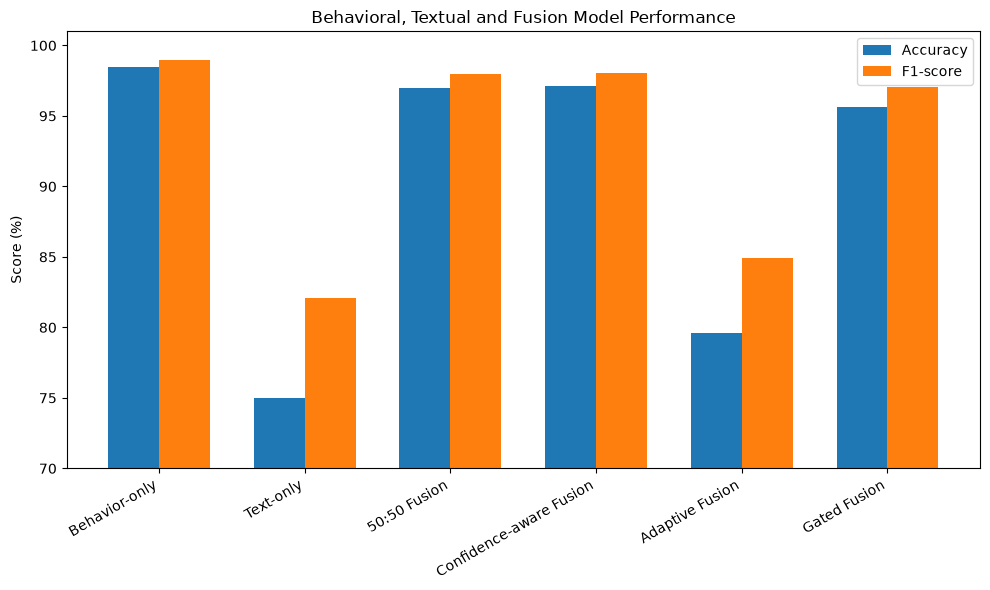

In [7]:
# ============================================================
# FUSION PERFORMANCE COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

x = np.arange(len(fusion_results))
width = 0.35

plt.bar(x - width/2, fusion_results["Accuracy"], width, label="Accuracy")
plt.bar(x + width/2, fusion_results["F1"], width, label="F1-score")

plt.xticks(x, fusion_results["Method"], rotation=30, ha="right")
plt.ylabel("Score (%)")
plt.title("Behavioral, Textual and Fusion Model Performance")
plt.ylim(70, 101)
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import numpy as np

## Fusion Analysis

The behavioral model achieved the strongest performance on the unseen
bot-category evaluation, with 98.44% accuracy and 98.95% F1-score.

The textual model achieved substantially lower performance under the
same unseen-category setting, with 75.01% accuracy and 82.06% F1-score.

The 50:50 and confidence-aware fusion approaches achieved 97.01% and
97.11% accuracy respectively. Although these approaches combine
behavioral and textual evidence, they did not outperform the behavioral
model on the unseen-category test.

This indicates that combining multiple modalities does not automatically
improve robustness. The usefulness of fusion depends on how well each
individual modality generalizes to the unseen distribution.

Therefore, the behavioral model is retained as the strongest baseline
for the robustness evaluation, while textual information is treated as
complementary evidence.

In [8]:
# ============================================================
# RELIABILITY ANALYSIS
# ============================================================

reliability_results = pd.DataFrame([
    {
        "Decision": "Automatic",
        "Count": 4088,
        "Coverage": 95.40,
        "Accuracy": 99.63
    },
    {
        "Decision": "Review",
        "Count": 197,
        "Coverage": 4.60,
        "Accuracy": 73.60
    }
])

reliability_results

,Decision,Count,Coverage,Accuracy
0,Automatic,4088,95.4,99.63
1,Review,197,4.6,73.60


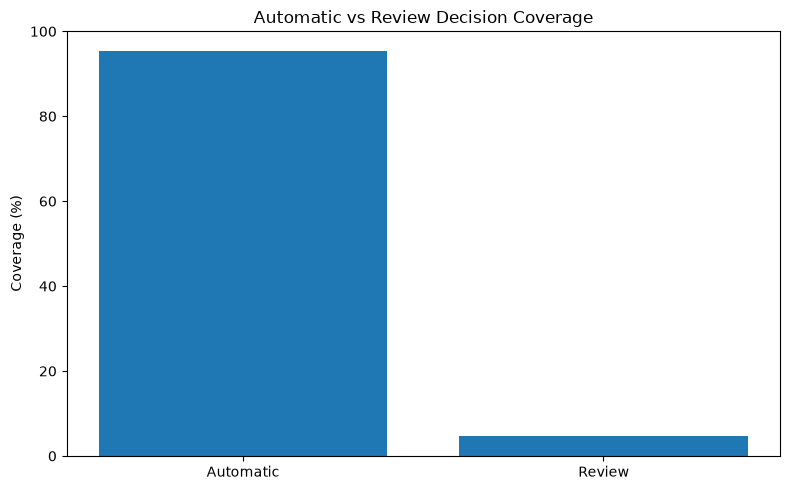

In [9]:
# ============================================================
# RELIABILITY COVERAGE
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    reliability_results["Decision"],
    reliability_results["Coverage"]
)

plt.ylabel("Coverage (%)")
plt.title("Automatic vs Review Decision Coverage")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

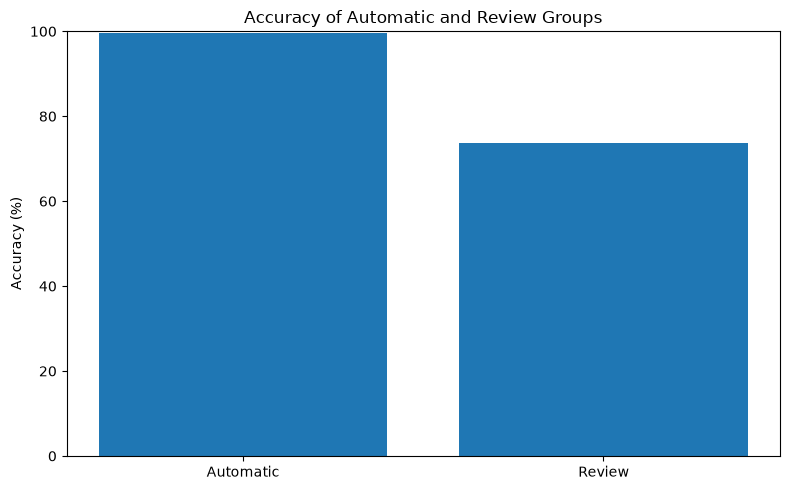

In [10]:
# ============================================================
# RELIABILITY ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    reliability_results["Decision"],
    reliability_results["Accuracy"]
)

plt.ylabel("Accuracy (%)")
plt.title("Accuracy of Automatic and Review Groups")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

## Reliability Analysis

A confidence-based reliability layer was introduced to distinguish
high-confidence predictions from uncertain predictions.

A confidence threshold of 0.95 was selected using the validation data.

On the unseen-category test:

- 4,088 accounts (95.40%) were classified automatically.
- The automatic group achieved 99.63% accuracy.
- 197 accounts (4.60%) were routed for review.
- The review group achieved 73.60% accuracy.

The reliability layer therefore allows the system to automate a large
proportion of high-confidence predictions while identifying uncertain
cases for additional review.

Importantly, reliability is separate from model accuracy. A prediction
can be correct or incorrect, while reliability represents how confident
the system is in that prediction.

## Behavioral Drift Analysis

Behavioral drift analysis measures how unusual an account's behavioral
pattern is compared with the distribution observed during model training.

The analysis uses the Mahalanobis distance to measure the multivariate
distance between an account and the training distribution.

A higher drift score indicates that an account's behavioral characteristics
are more unusual relative to the known training population.

Drift is used as contextual information about distribution shift rather
than as a direct replacement for the bot classifier's prediction.

For the unseen-category evaluation, the drift distribution was compared
between training, validation, and test accounts to assess whether the
unseen Fake Followers exhibit behavioral patterns different from the
known training categories.

In [11]:
# ============================================================
# DRIFT DISTRIBUTION
# ============================================================

drift_summary = pd.DataFrame([
    {
        "Dataset": "Training",
        "Mean Drift": 12.0467,
        "Median Drift": 4.1470,
        "95th Percentile": 24.2735,
        "99th Percentile": 97.1413
    },
    {
        "Dataset": "Validation",
        "Mean Drift": 0.5038,
        "Median Drift": 0.5004,
        "95th Percentile": 0.9553,
        "99th Percentile": 0.9938
    },
    {
        "Dataset": "Unseen Test",
        "Mean Drift": 0.7536,
        "Median Drift": 0.7875,
        "95th Percentile": 0.9966,
        "99th Percentile": 0.9993
    }
])

drift_summary

,Dataset,Mean Drift,Median Drift,95th Percentile,99th Percentile
0,Training,12.0467,4.1470,24.2735,97.1413
1,Validation,0.5038,0.5004,0.9553,0.9938
2,Unseen Test,0.7536,0.7875,0.9966,0.9993


In [12]:
# ============================================================
# DRIFT-BASED GROUPS
# ============================================================

drift_groups = pd.DataFrame([
    {
        "Drift Group": "Reliable",
        "Drift Range": "< 0.80",
        "Accounts": 2185,
        "Accuracy": 80.32
    },
    {
        "Drift Group": "Review",
        "Drift Range": "0.80 - < 0.95",
        "Accounts": 1257,
        "Accuracy": 84.33
    },
    {
        "Drift Group": "High Drift / Low Reliability",
        "Drift Range": ">= 0.95",
        "Accounts": 843,
        "Accuracy": 70.58
    }
])

drift_groups

,Drift Group,Drift Range,Accounts,Accuracy
0,Reliable,< 0.80,2185,80.32
1,Review,0.80 - < 0.95,1257,84.33
2,High Drift / Low Reliability,>= 0.95,843,70.58


### Drift Analysis Finding

The unseen test distribution shows higher drift than the validation
distribution, indicating that the unseen category contains behavioral
patterns that differ from the known training population.

Accounts with high drift also show lower prediction accuracy in the
analyzed groups.

However, drift alone is not used to determine whether a prediction is
correct or incorrect. It is treated as an additional signal describing
how unusual an account is relative to the training distribution.

The confidence-based reliability layer remains the primary mechanism for
automatic versus review decisions, while drift provides additional
context about distribution shift.

## SHAP-Based Explainability

To improve interpretability, SHAP (SHapley Additive exPlanations) was
used to analyze the contribution of behavioral features to the neural
network's predictions.

The analysis explains:
1. Which behavioral features are most influential overall.
2. How individual feature values contribute toward a bot or genuine
   prediction for a particular account.

SHAP values indicate the contribution of a feature to the model's
prediction. They describe model behavior and should not be interpreted
as causal relationships.

In [13]:
# ============================================================
# LOAD SHAP RESULTS
# ============================================================

shap_importance = pd.read_csv(
    "../data/final_results/shap_feature_importance.csv"
)

individual_shap = pd.read_csv(
    "../data/final_results/individual_shap_explanation.csv"
)

print("SHAP feature importance:")
display(shap_importance)

print("\nIndividual SHAP explanations:")
display(individual_shap)

SHAP feature importance:


,Feature,Mean_Absolute_SHAP
0,log_favourites_count,0.320701
1,account_age_days,0.108996
2,friends_followers_ratio,0.037197
3,favorites_per_status,0.026051
4,log_followers_count,0.017173
5,log_statuses_count,0.014660
6,log_friends_count,0.012603
7,log_listed_count,0.008304
8,statuses_per_day,0.007894
9,friends_count,0.007775



Individual SHAP explanations:


,Feature,Feature Value,SHAP Value,Direction,Absolute SHAP
0,friends_followers_ratio,138.333333,0.166570,Pushes toward BOT,0.166570
1,log_favourites_count,0.000000,0.079115,Pushes toward BOT,0.079115
2,account_age_days,942.611042,0.072337,Pushes toward BOT,0.072337
3,log_followers_count,1.386294,-0.030155,Pushes toward GENUINE,0.030155
4,log_statuses_count,0.693147,0.011010,Pushes toward BOT,0.011010
5,followers_count,3.000000,0.004733,Pushes toward BOT,0.004733
6,statuses_count,1.000000,-0.004700,Pushes toward GENUINE,0.004700
7,favorites_per_status,0.000000,0.004169,Pushes toward BOT,0.004169
8,friends_count,415.000000,-0.003333,Pushes toward GENUINE,0.003333
9,followers_friends_ratio,0.007229,0.000850,Pushes toward BOT,0.000850


In [14]:
# ============================================================
# TOP SHAP FEATURES
# ============================================================

shap_top5 = pd.DataFrame([
    {
        "Rank": 1,
        "Feature": "log_favourites_count",
        "Mean Absolute SHAP": 0.3207
    },
    {
        "Rank": 2,
        "Feature": "account_age_days",
        "Mean Absolute SHAP": 0.1090
    },
    {
        "Rank": 3,
        "Feature": "friends_followers_ratio",
        "Mean Absolute SHAP": 0.0372
    },
    {
        "Rank": 4,
        "Feature": "favorites_per_status",
        "Mean Absolute SHAP": 0.0261
    },
    {
        "Rank": 5,
        "Feature": "log_followers_count",
        "Mean Absolute SHAP": 0.0172
    }
])

shap_top5

,Rank,Feature,Mean Absolute SHAP
0,1,log_favourites_count,0.3207
1,2,account_age_days,0.1090
2,3,friends_followers_ratio,0.0372
3,4,favorites_per_status,0.0261
4,5,log_followers_count,0.0172


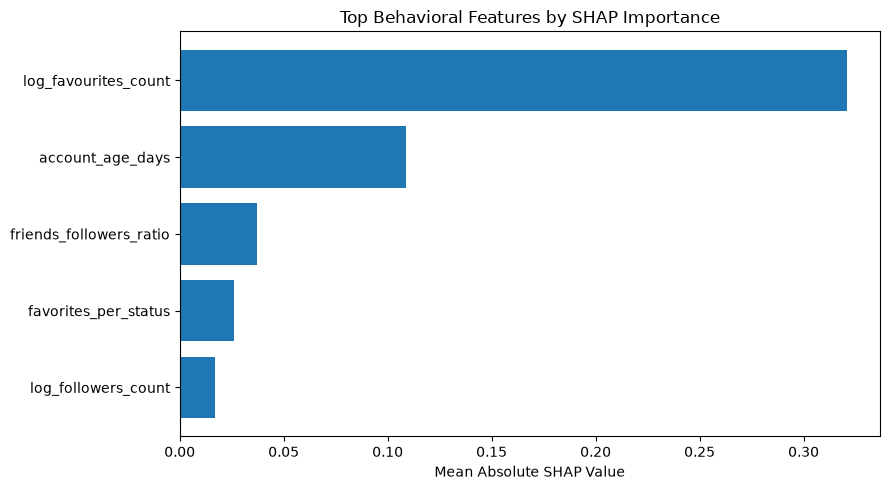

In [15]:
# ============================================================
# TOP 5 SHAP FEATURE IMPORTANCE
# ============================================================

plt.figure(figsize=(9, 5))

plt.barh(
    shap_top5["Feature"][::-1],
    shap_top5["Mean Absolute SHAP"][::-1]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.title("Top Behavioral Features by SHAP Importance")

plt.tight_layout()
plt.show()

### SHAP Findings

The most influential feature in the analyzed sample was
`log_favourites_count`, followed by `account_age_days` and
`friends_followers_ratio`.

The SHAP analysis indicates that:

- Higher `log_favourites_count` values generally contributed toward
  genuine-account predictions, while lower values tended to contribute
  toward bot predictions.
- Higher `account_age_days` generally contributed toward genuine-account
  predictions.
- Higher `friends_followers_ratio` generally contributed toward
  bot predictions.
- Higher `favorites_per_status` generally contributed toward
  genuine-account predictions.

These are model-level associations observed in the analyzed sample and
should not be interpreted as universal or causal rules.

In [17]:
# ============================================================
# INDIVIDUAL ACCOUNT EXPLANATION
# ============================================================

individual_example = pd.DataFrame([
    ["friends_followers_ratio", 0.167, "BOT"],
    ["log_favourites_count", 0.079, "BOT"],
    ["account_age_days", 0.072, "BOT"],
    ["log_followers_count", -0.030, "GENUINE"],
    ["log_statuses_count", 0.011, "BOT"]
], columns=[
    "Feature",
    "SHAP Contribution",
    "Direction"
])

individual_example

,Feature,SHAP Contribution,Direction
0,friends_followers_ratio,0.167,BOT
1,log_favourites_count,0.079,BOT
2,account_age_days,0.072,BOT
3,log_followers_count,-0.030,GENUINE
4,log_statuses_count,0.011,BOT


### Example Prediction

For one analyzed account:

- Actual class: **BOT**
- Model prediction: **BOT**
- Bot probability: **100.00%**

The largest contribution toward the bot prediction came from
`friends_followers_ratio`.

This demonstrates how SHAP can provide an explanation for an individual
model decision rather than returning only a binary prediction.

## Temporal Behavioral Evolution Analysis

Traditional behavioral bot detection often represents an account using
static aggregate statistics.

To investigate whether the evolution of account activity provides
additional information, temporal behavioral features were extracted from
tweet timestamps.

Three temporal patterns were investigated:

1. Intertweet timing
2. Posting-time behavior
3. Activity variability

These temporal features were evaluated together with the original
15 behavioral features using the same Leave-One-Bot-Type-Out protocol.

Fake Followers were kept completely unseen during training.

In [18]:
# ============================================================
# TEMPORAL BEHAVIORAL EVOLUTION RESULTS
# ============================================================

temporal_results = pd.DataFrame([
    {
        "Experiment": "Behavioral Baseline",
        "Feature Set": "15 Behavioral",
        "Accuracy": 98.44,
        "Precision": 99.75,
        "Recall": 98.16,
        "F1": 98.95
    },
    {
        "Experiment": "Intertweet Only",
        "Feature Set": "2 Temporal",
        "Accuracy": 90.25,
        "Precision": 96.22,
        "Recall": 90.51,
        "F1": 93.27
    },
    {
        "Experiment": "Posting-time Only",
        "Feature Set": "3 Temporal",
        "Accuracy": 88.68,
        "Precision": 97.62,
        "Recall": 86.98,
        "F1": 91.99
    },
    {
        "Experiment": "Activity Variability Only",
        "Feature Set": "3 Temporal",
        "Accuracy": 82.38,
        "Precision": 92.47,
        "Recall": 83.20,
        "F1": 87.59
    },
    {
        "Experiment": "Behavior + Posting-time",
        "Feature Set": "18 Features",
        "Accuracy": 98.69,
        "Precision": 99.68,
        "Recall": 98.56,
        "F1": 99.12
    },
    {
        "Experiment": "Behavior + Activity",
        "Feature Set": "18 Features",
        "Accuracy": 98.76,
        "Precision": 99.72,
        "Recall": 98.63,
        "F1": 99.17
    },
    {
        "Experiment": "Behavior + Intertweet",
        "Feature Set": "17 Features",
        "Accuracy": 98.83,
        "Precision": 99.53,
        "Recall": 98.91,
        "F1": 99.22
    },
    {
        "Experiment": "Behavior + Intertweet + Activity",
        "Feature Set": "20 Features",
        "Accuracy": 98.90,
        "Precision": 99.69,
        "Recall": 98.84,
        "F1": 99.26
    },
    {
        "Experiment": "Behavior + Intertweet + Posting-time",
        "Feature Set": "20 Features",
        "Accuracy": 98.20,
        "Precision": 99.90,
        "Recall": 97.69,
        "F1": 98.78
    },
    {
        "Experiment": "Full Temporal",
        "Feature Set": "23 Features",
        "Accuracy": 98.18,
        "Precision": 99.81,
        "Recall": 97.75,
        "F1": 98.77
    }
])

temporal_results

,Experiment,Feature Set,Accuracy,Precision,Recall,F1
0,Behavioral Baseline,15 Behavioral,98.44,99.75,98.16,98.95
1,Intertweet Only,2 Temporal,90.25,96.22,90.51,93.27
2,Posting-time Only,3 Temporal,88.68,97.62,86.98,91.99
3,Activity Variability Only,3 Temporal,82.38,92.47,83.20,87.59
4,Behavior + Posting-time,18 Features,98.69,99.68,98.56,99.12
5,Behavior + Activity,18 Features,98.76,99.72,98.63,99.17
6,Behavior + Intertweet,17 Features,98.83,99.53,98.91,99.22
7,Behavior + Intertweet + Activity,20 Features,98.90,99.69,98.84,99.26
8,Behavior + Intertweet + Posting-time,20 Features,98.20,99.90,97.69,98.78
9,Full Temporal,23 Features,98.18,99.81,97.75,98.77


In [19]:
# ============================================================
# BEST TEMPORAL CONFIGURATION
# ============================================================

best_temporal = temporal_results.loc[
    temporal_results["F1"].idxmax()
]

baseline_temporal = temporal_results[
    temporal_results["Experiment"] == "Behavioral Baseline"
].iloc[0]

accuracy_improvement = (
    best_temporal["Accuracy"] - baseline_temporal["Accuracy"]
)

f1_improvement = (
    best_temporal["F1"] - baseline_temporal["F1"]
)

print("BEST TEMPORAL CONFIGURATION")
print("=" * 60)

print("Experiment:", best_temporal["Experiment"])
print("Feature Set:", best_temporal["Feature Set"])
print("Accuracy:", best_temporal["Accuracy"], "%")
print("Precision:", best_temporal["Precision"], "%")
print("Recall:", best_temporal["Recall"], "%")
print("F1:", best_temporal["F1"], "%")

print("\nImprovement over behavioral baseline:")
print(f"Accuracy: +{accuracy_improvement:.2f} percentage points")
print(f"F1: +{f1_improvement:.2f} percentage points")

BEST TEMPORAL CONFIGURATION
Experiment: Behavior + Intertweet + Activity
Feature Set: 20 Features
Accuracy: 98.9 %
Precision: 99.69 %
Recall: 98.84 %
F1: 99.26 %

Improvement over behavioral baseline:
Accuracy: +0.46 percentage points
F1: +0.31 percentage points


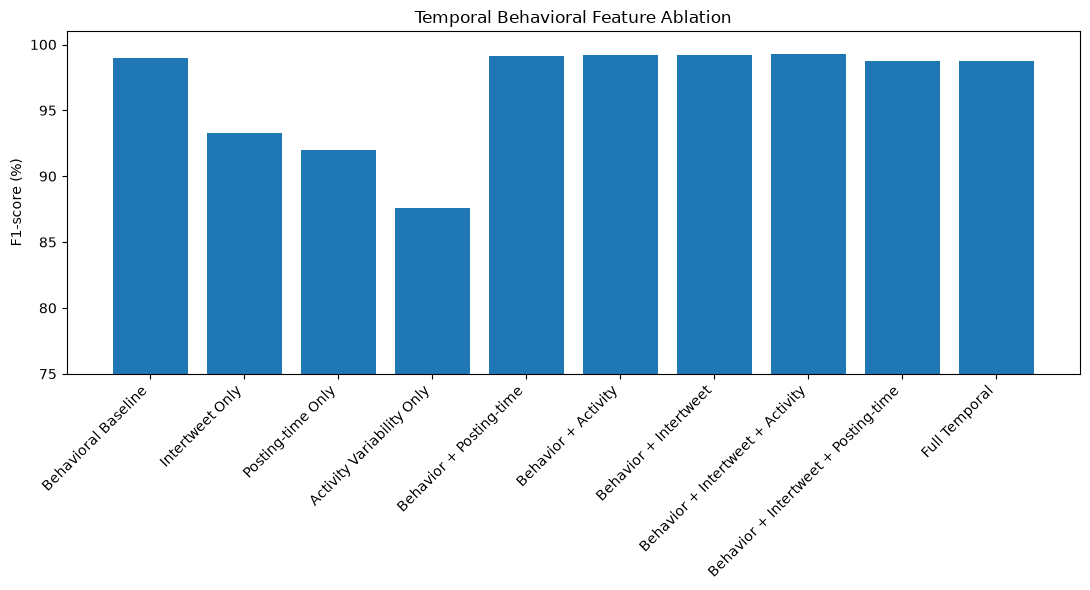

In [20]:
# ============================================================
# TEMPORAL F1 COMPARISON
# ============================================================

plt.figure(figsize=(11, 6))

plt.bar(
    temporal_results["Experiment"],
    temporal_results["F1"]
)

plt.ylabel("F1-score (%)")
plt.title("Temporal Behavioral Feature Ablation")
plt.xticks(rotation=45, ha="right")
plt.ylim(75, 101)

plt.tight_layout()
plt.show()

### Temporal Behavioral Evolution Findings

The strongest temporal configuration combined the original 15 behavioral
features with intertweet timing and activity-variability features.

This configuration achieved:

- Accuracy: 98.90%
- Precision: 99.69%
- Recall: 98.84%
- F1-score: 99.26%

Compared with the 15-feature behavioral baseline of 98.44% accuracy and
98.95% F1-score, this represents an improvement of:

- 0.46 percentage points in accuracy
- 0.31 percentage points in F1-score

The ablation experiments show that temporal information can provide
additional predictive information, but adding more temporal features does
not necessarily improve performance.

In particular, the full 23-feature temporal configuration performed
worse than the selected 20-feature configuration.

Therefore, temporal behavioral features should be selected based on
their contribution to generalization rather than simply increasing the
number of features.

These results are exploratory because multiple temporal configurations
were evaluated on the same unseen-category test set.

In [21]:
# ============================================================
# MASTER RESULTS COMPARISON
# ============================================================

master_results = pd.DataFrame([
    {
        "Experiment": "Behavior-only",
        "Accuracy": 98.44,
        "Precision": 99.75,
        "Recall": 98.16,
        "F1": 98.95
    },
    {
        "Experiment": "Text-only",
        "Accuracy": 75.01,
        "Precision": 88.48,
        "Recall": 76.51,
        "F1": 82.06
    },
    {
        "Experiment": "50:50 Fusion",
        "Accuracy": 97.01,
        "Precision": None,
        "Recall": None,
        "F1": 97.98
    },
    {
        "Experiment": "Confidence-aware Fusion",
        "Accuracy": 97.11,
        "Precision": None,
        "Recall": None,
        "F1": 98.04
    },
    {
        "Experiment": "Gated Fusion",
        "Accuracy": 95.61,
        "Precision": None,
        "Recall": None,
        "F1": 97.05
    },
    {
        "Experiment": "Adaptive Fusion",
        "Accuracy": 79.58,
        "Precision": None,
        "Recall": None,
        "F1": 84.92
    },
    {
        "Experiment": "Temporal Best",
        "Accuracy": 98.90,
        "Precision": 99.69,
        "Recall": 98.84,
        "F1": 99.26
    }
])

master_results

,Experiment,Accuracy,Precision,Recall,F1
0,Behavior-only,98.44,99.75,98.16,98.95
1,Text-only,75.01,88.48,76.51,82.06
2,50:50 Fusion,97.01,NaN,NaN,97.98
3,Confidence-aware Fusion,97.11,NaN,NaN,98.04
4,Gated Fusion,95.61,NaN,NaN,97.05
5,Adaptive Fusion,79.58,NaN,NaN,84.92
6,Temporal Best,98.90,99.69,98.84,99.26


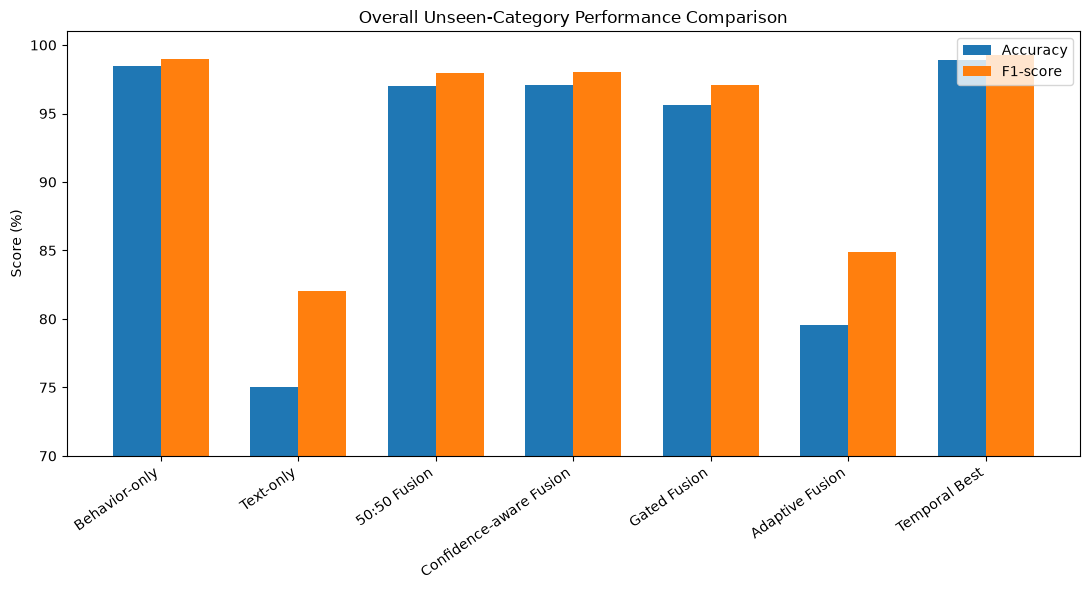

In [22]:
# ============================================================
# MASTER PERFORMANCE COMPARISON
# ============================================================

plt.figure(figsize=(11, 6))

x = np.arange(len(master_results))
width = 0.35

plt.bar(
    x - width/2,
    master_results["Accuracy"],
    width,
    label="Accuracy"
)

plt.bar(
    x + width/2,
    master_results["F1"],
    width,
    label="F1-score"
)

plt.xticks(
    x,
    master_results["Experiment"],
    rotation=35,
    ha="right"
)

plt.ylabel("Score (%)")
plt.title("Overall Unseen-Category Performance Comparison")
plt.ylim(70, 101)
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# BEST OVERALL RESULT
# ============================================================

best_accuracy = master_results.loc[
    master_results["Accuracy"].idxmax()
]

best_f1 = master_results.loc[
    master_results["F1"].idxmax()
]

print("Highest Accuracy:")
print(best_accuracy["Experiment"], "-", best_accuracy["Accuracy"], "%")

print("\nHighest F1-score:")
print(best_f1["Experiment"], "-", best_f1["F1"], "%")

Highest Accuracy:
Temporal Best - 98.9 %

Highest F1-score:
Temporal Best - 99.26 %


## Final Experimental Summary

The experiments were designed to evaluate not only standard classification
performance but also generalization to an unseen bot category.

The main findings are:

### 1. Behavioral detection

The behavioral neural network achieved 98.44% accuracy and 98.95% F1-score
under the LOBO evaluation, demonstrating strong generalization to the
unseen Fake Followers category.

### 2. Textual detection

The textual model achieved 75.01% accuracy and 82.06% F1-score under the
same unseen-category evaluation. Its lower performance demonstrates that
textual patterns alone are less robust to this distribution shift.

### 3. Fusion

Several behavioral-textual fusion strategies were evaluated. Although
fusion performed strongly under validation, none of the tested fusion
approaches consistently exceeded the behavioral model on the unseen
category.

This demonstrates that multimodal fusion does not automatically guarantee
better cross-category generalization.

### 4. Reliability

A confidence-based reliability layer allowed 95.40% of unseen test
accounts to be handled automatically at 99.63% accuracy, while uncertain
cases were routed for review.

### 5. Drift

Mahalanobis-based behavioral drift analysis provided an additional measure
of how unusual an account was relative to the training distribution.
Drift was used as contextual information rather than as a direct
classification decision.

### 6. Explainability

SHAP analysis provided both global feature importance and individual
prediction explanations, making the behavioral model more interpretable.

### 7. Temporal behavioral evolution

Adding selected temporal behavioral features improved the unseen-category
result from 98.44% to 98.90% accuracy and from 98.95% to 99.26% F1-score.

However, the full temporal feature set performed worse, showing that
additional features do not necessarily improve generalization.

# Final Conclusion

This project presents a behavioral and textual framework for social media
bot detection with an emphasis on robustness, reliability and
interpretability.

The evaluation shows that standard validation performance alone is not
sufficient to measure bot-detection robustness. Therefore, the system was
evaluated using Leave-One-Bot-Type-Out testing, where Fake Followers were
excluded from training and treated as an unseen bot category.

The behavioral model demonstrated strong generalization, achieving 98.44%
accuracy and 98.95% F1-score. Textual information provided complementary
evidence but showed substantially weaker generalization under the same
unseen-category setting.

A reliability layer was introduced to distinguish high-confidence
predictions from uncertain cases, while behavioral drift analysis provided
additional information about distribution shift. SHAP explainability was
used to understand the behavioral features contributing to predictions.

Finally, temporal behavioral features were investigated to capture patterns
of account activity over time. The best selected temporal configuration
improved performance to 98.90% accuracy and 99.26% F1-score on the unseen
category.

Overall, the results support a robustness-oriented approach in which
behavioral evidence forms the strongest detection component, while
textual evidence, confidence, drift, explainability and temporal
information provide complementary layers for analysis and decision
support.